In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

In [ ]:
%cd "/content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week01/material"
image_directory = os.getcwd()
image_arrays = []
for filename in os.listdir(image_directory):
  try:
    image_path = os.path.join(image_directory, filename)
    image_arr = np.array(Image.open(image_path).convert("L"), dtype = float)
    image_arrays.append(image_arr)
    print(f"Loaded {filename} : {image_arr.shape}")
  except Exception as e:
    print(f"Error loading '{filename}': {e}")

/content/drive/MyDrive/MLIotLab_HCMUT/mliot-pyml-2026-hw/week01/material
Loaded image1.jpg : (675, 1200)
Loaded image2.jpg : (1200, 675)
Loaded image4.jpg : (256, 192)
Loaded image5.jpg : (1477, 800)
Loaded image6.jpg : (148, 204)
Loaded image3.jpg : (465, 618)
Loaded image7.jpg : (288, 460)
Loaded image8.jpg : (711, 431)
Loaded image9.jpg : (700, 700)


In [ ]:
def cosine_similarity(X, Y=None):
  if Y is None:
    Y = X
  Xn = X / np.linalg.norm(X, axis=1, keepdims=True)
  Yn = Y / np.linalg.norm(Y, axis=1, keepdims=True)
  return Xn @ Yn.T


In [ ]:
def findImageDimension(image_arrays):
  shapes = np.array([img.shape for img in image_arrays])

  medians = np.median(shapes, axis=0)

  median_h = int(np.round(medians[0]))
  median_w = int(np.round(medians[1]))

  return (median_h, median_w)

In [ ]:
def resizeImageArray(image_arrays):
  image_dimension = findImageDimension(image_arrays)
  resize_array = []
  for img_array in image_arrays:
    # Ensure array is uint8 for PIL Image.fromarray when input is float
    img_pil = Image.fromarray(img_array.astype(np.uint8))
    image_resize = img_pil.resize((image_dimension[1], image_dimension[0]))
    temp = np.array(image_resize).flatten()
    resize_array.append(temp)
  return resize_array

In [ ]:
X = np.array(resizeImageArray(image_arrays))
print("X: ",X.shape)

X:  (9, 417150)


In [ ]:
X_mean = np.mean(X, axis=0)
print("X_mean: ", X_mean.shape)
X_centered = X - X_mean
print("X_centered: ", X_centered.shape)

X_mean:  (417150,)
X_centered:  (9, 417150)


In [ ]:
X_cosine = cosine_similarity(X_centered)
X_cosine

array([[ 1.        ,  0.55494195, -0.25322361, -0.7176246 , -0.46844956,
         0.24046125,  0.34030947, -0.13429729,  0.07955863],
       [ 0.55494195,  1.        , -0.27086046, -0.64443672, -0.49123662,
         0.28281455,  0.22449412, -0.13325073,  0.21774093],
       [-0.25322361, -0.27086046,  1.        ,  0.26896609, -0.03310562,
        -0.18710665, -0.38962509, -0.20536063, -0.44296866],
       [-0.7176246 , -0.64443672,  0.26896609,  1.        ,  0.38414059,
        -0.43534514, -0.42287665, -0.05851406, -0.34594344],
       [-0.46844956, -0.49123662, -0.03310562,  0.38414059,  1.        ,
        -0.37052851, -0.35964011, -0.09547628, -0.17315601],
       [ 0.24046125,  0.28281455, -0.18710665, -0.43534514, -0.37052851,
         1.        , -0.04269307, -0.05382205,  0.38787108],
       [ 0.34030947,  0.22449412, -0.38962509, -0.42287665, -0.35964011,
        -0.04269307,  1.        ,  0.0270636 , -0.12424007],
       [-0.13429729, -0.13325073, -0.20536063, -0.05851406, -0

In [76]:
def search(query, top_k=9):
  query = query.reshape(1,-1)
  query_centered = query - X_mean
  scores = cosine_similarity(query_centered, X_centered).flatten()
  top_indices = np.argsort(scores)[::-1][:top_k]

  print(f"Top {top_k}")
  for i, idx in enumerate(top_indices):
    print(f"Top {i+1} Image Similarity : Image {idx} | Cosine similarity: {scores[idx]}")
  return top_indices, scores[top_indices]

query_sample = X_centered[0]
top_indices, scores = search(query_sample)

Top 9
Top 1 Image Similarity : Image 3 | Cosine similarity: 0.6653683096477141
Top 2 Image Similarity : Image 4 | Cosine similarity: 0.5102542944761899
Top 3 Image Similarity : Image 2 | Cosine similarity: 0.220887666889357
Top 4 Image Similarity : Image 7 | Cosine similarity: 0.10190339740377309
Top 5 Image Similarity : Image 6 | Cosine similarity: -0.27591183211389764
Top 6 Image Similarity : Image 5 | Cosine similarity: -0.3446529777457146
Top 7 Image Similarity : Image 8 | Cosine similarity: -0.43124139810724194
Top 8 Image Similarity : Image 0 | Cosine similarity: -0.47025926035579335
Top 9 Image Similarity : Image 1 | Cosine similarity: -0.7196882920661015


Comment: Image 1 is the most different from Image 0

Comment: Image 3 is the most similar from Image 0

Result: The result matches with my intuition


**Bài 2 — Biến đổi tuyến tính & SVD**

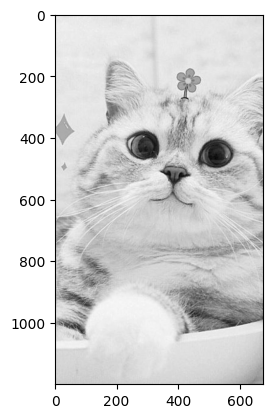

In [60]:
image_sample = np.array(Image.open("image2.jpg").convert("L"), dtype=float) /255.0
plt.imshow(image_sample, cmap='gray')

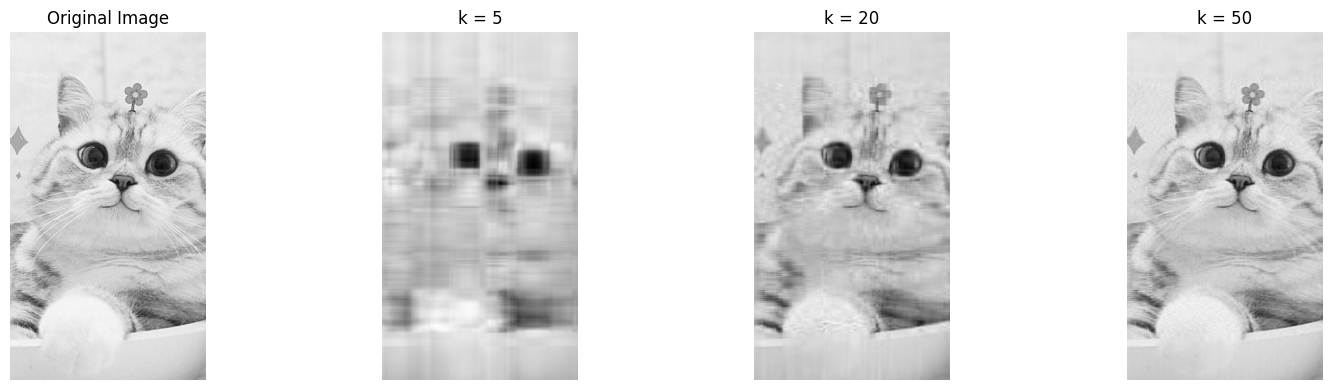

In [61]:
U, Sigma, Vt = np.linalg.svd(image_sample, full_matrices=False)
def reconstruct(k):
  return (U[:, :k] * Sigma[:k] @ Vt[:k, :])


k_values = [5, 20, 50]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(image_sample, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

for i, k in enumerate(k_values):
  img_k = reconstruct(k)
  axes[i+1].imshow(img_k, cmap='gray')
  axes[i+1].set_title(f'k = {k}')
  axes[i+1].axis('off')

plt.tight_layout()
plt.show()

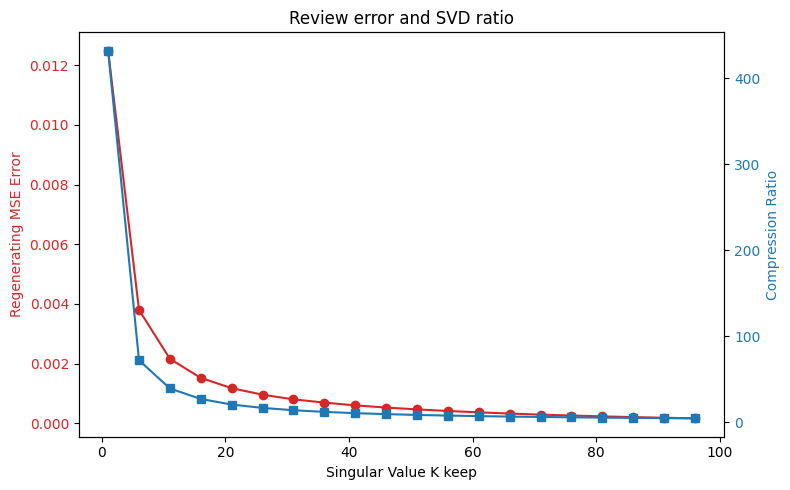

In [70]:
m, n = image_sample.shape
origin_size = m * n
k_range = list(range(1, min(100, m, n), 5))
errors = []
comp_ratios = []
for k in k_range:
  img_k = reconstruct(k)
  mse = np.mean((image_sample - img_k) ** 2)
  errors.append(mse)
  comp_size = (m * k) + k + (k * n)
  comp_ratios.append(origin_size / comp_size)

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_xlabel('Singular Value K keep')
ax1.set_ylabel('Regenerating MSE Error', color='tab:red')
ax1.plot(k_range, errors, color='tab:red', marker='o', label='MSE')
ax1.tick_params(axis='y', labelcolor='tab:red')

ax2 = ax1.twinx()
ax2.set_ylabel('Compression Ratio', color='tab:blue')
ax2.plot(k_range, comp_ratios, color='tab:blue', marker='s', label='Compression Ratio')
ax2.tick_params(axis='y', labelcolor='tab:blue')

plt.title('Review error and SVD ratio')
fig.tight_layout()
plt.show()


k>=90 is approximate Original Picture

 Kích thước vector S gốc: 675
 Số lượng giá trị kỳ dị k cần giữ lại để đạt >= 90% thông tin: k = 1
 Tỷ lệ nén số lượng đặc trưng: Giảm từ 675 chiều xuống còn 1 chiều.


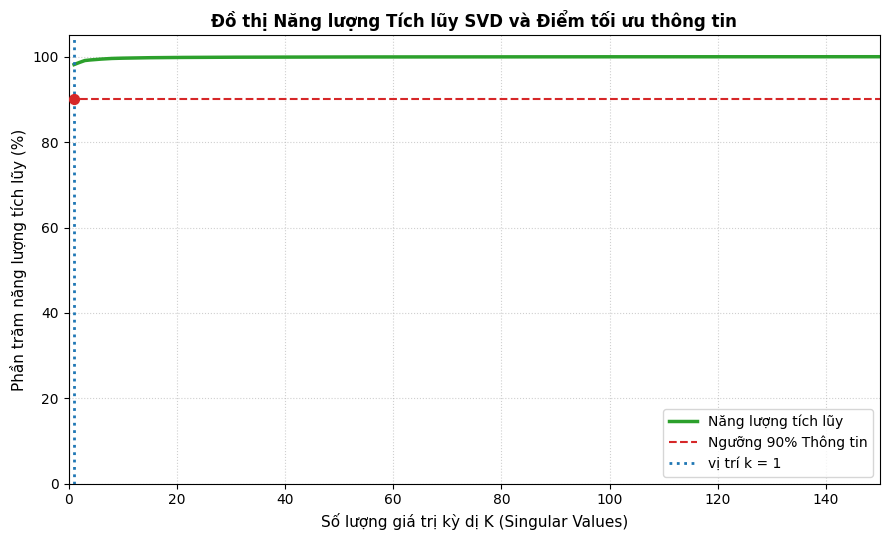

In [75]:
total_energy = np.sum(Sigma ** 2)
cumulative_energy = np.cumsum(Sigma ** 2) / total_energy
k_90 = np.argmax(cumulative_energy >= 0.90) + 1

print(f" Kích thước vector S gốc: {len(Sigma)}")
print(f" Số lượng giá trị kỳ dị k cần giữ lại để đạt >= 90% thông tin: k = {k_90}")
print(f" Tỷ lệ nén số lượng đặc trưng: Giảm từ {len(Sigma)} chiều xuống còn {k_90} chiều.")

# 3. Tiến hành vẽ đồ thị năng lượng tích lũy theo k
plt.figure(figsize=(9, 5.5))

# Vẽ đường cong năng lượng tích lũy (chuyển sang đơn vị %)
plt.plot(range(1, len(Sigma) + 1), cumulative_energy * 100, color='tab:green', linewidth=2.5, label='Năng lượng tích lũy')

# Vẽ đường giới hạn ngưỡng 90% để đối chiếu
plt.axhline(y=90, color='tab:red', linestyle='--', linewidth=1.5, label='Ngưỡng 90% Thông tin')

# Vẽ đường thẳng đứng đánh dấu vị trí k tìm được
plt.axvline(x=k_90, color='tab:blue', linestyle=':', linewidth=2, label=f'vị trí k = {k_90}')

# Đánh dấu điểm giao nhau trên đồ thị
plt.scatter(k_90, 90, color='tab:red', s=50, zorder=5)

# Thiết lập thông tin nhãn trục và tiêu đề
plt.xlabel('Số lượng giá trị kỳ dị K (Singular Values)', fontsize=11)
plt.ylabel('Phần trăm năng lượng tích lũy (%)', fontsize=11)
plt.title('Đồ thị Năng lượng Tích lũy SVD và Điểm tối ưu thông tin', fontsize=12, fontweight='bold')
plt.xlim(0, min(150, len(Sigma))) # Giới hạn trục X ngắn lại để dễ quan sát đoạn dốc đầu
plt.ylim(0, 105)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.show()

Comment $k=1$ giữ $\ge 90\%$ thông tin chỉ là thông tin về độ lớn cường độ sáng, chứ không phải thông tin về cấu trúc hình ảnh.